In [156]:
from pynq import Overlay, DefaultIP, MMIO, allocate 
import numpy as np
from enum import Enum
import time
import struct
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wave

BRAM_ADDR = 0x80010000
ADDRESS_RANGE = 0x1000
ADDRESS_OFFSET = 0x00
bram = MMIO(BRAM_ADDR,ADDRESS_RANGE)

class Registers():
    NUM_TAPS_OFFSET = 0
    LOWER_CUTOFF_OFFSET = 1
    UPPER_CUTOFF_OFFSET = 2
    SAMPLING_RATE_OFFSET = 3
    READ_SUCCESS_OFFSET = 4
    RESET_OFFSET = 5
    SIZE_OFFSET = 6

MAX_AMP = (2**15) -1
V_HIGH  = 3.3
PERIOD  = 0.01        # 10ms period
FS      = 100000      # samples/sec

def plot_pwm(input_val):
    duty = min(input_val / MAX_AMP, 1.0)
    duty_pct = duty * 100
    avg_v = duty * V_HIGH

    # Build one period of PWM
    t = np.linspace(0, PERIOD, int(FS * PERIOD), endpoint=False)
    on_samples = int(duty * len(t))
    pwm = np.zeros(len(t))
    pwm[:on_samples] = V_HIGH

    # Repeat for 3 periods
    t_full   = np.concatenate([t + i * PERIOD for i in range(3)])
    pwm_full = np.tile(pwm, 3)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.step(t_full * 1000, pwm_full, where='post', color='#1D9E75', linewidth=2)
    ax.fill_between(t_full * 1000, pwm_full, step='post', alpha=0.15, color='#1D9E75')
    ax.axhline(avg_v, color='#D85A30', linewidth=1.2, linestyle='--', label=f'Avg voltage: {avg_v:.2f} V')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'PWM Signal  |  Input: {input_val}  |  Duty cycle: {duty_pct:.1f}%  |  Avg: {avg_v:.2f} V')
    ax.set_ylim(-0.4, 4.0)
    ax.set_yticks([0, V_HIGH])
    ax.set_yticklabels(['0 V', '3.3 V'])
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return duty
    
def plot_array(arr, fs):
    """
    arr: input signal
    fs: sampling frequency (samples per second)
    """
    N = len(arr)
    t = np.arange(N) / fs  # convert index → time

    plt.figure()
    plt.plot(t, arr)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Signal vs Time")
    plt.grid()
    plt.show() 
    
def hex(val):
    return f"0x{val:08X}"

        
class AddDriver(DefaultIP):
    bindto = ['xilinx.com:hls:firFilter:1.0']

    def process(self):
        self.write(0x10, BRAM_ADDR)
        print(hex(self.read(0x10)))

#load overlay
overlay = Overlay('Final_Motor.bit')
add_ip = overlay.firFilter
add_ip.write(0x10, BRAM_ADDR)

#add dma
dma = overlay.axi_dma 
dma_send = overlay.axi_dma.sendchannel 
dma_recv = overlay.axi_dma.recvchannel 

def set_bram_data(numTaps, lowerCutoff, upperCutoff, samplingRate):
    bram.write(Registers.NUM_TAPS_OFFSET * 4, numTaps)
    bram.write(Registers.LOWER_CUTOFF_OFFSET * 4, lowerCutoff)
    bram.write(Registers.UPPER_CUTOFF_OFFSET * 4, upperCutoff)
    bram.write(Registers.SAMPLING_RATE_OFFSET * 4, samplingRate)
    bram.write(Registers.READ_SUCCESS_OFFSET * 4, 0)
    
def findAverage(integerList):
    last_vals = integerList[-10:]
    return sum(last_vals) / len(last_vals)

def isFirReadingMem():
    return bram.read(Registers.READ_SUCCESS_OFFSET)

def resetSystem(): 
    bram.write(Registers.RESET_OFFSET*4, 0x1)

def generate_sine_samples(freq=100, sample_rate=100000, num_samples=100):
    t = np.linspace(0, num_samples/sample_rate, num_samples)
    sine = np.sin(2 * np.pi * freq * t)
    return (sine * 32767).astype(np.int32)

def stream(integerList):
    CONTROL_REGISTER = 0x0 
    data_size = len(integerList)
    input_buffer = allocate(shape=(data_size,), dtype=np.int32) 
    for i in range(len(integerList)): 
        input_buffer[i] = integerList[i]
    dma_send.transfer(input_buffer) 
    output_buffer = allocate(shape=(data_size,), dtype=np.int32) 
    dma_recv.transfer(output_buffer)
    dma_send.wait()
    dma_recv.wait()
    for i in range(len(integerList)): 
        integerList[i] = output_buffer[i] 
    del input_buffer, output_buffer 
    return integerList

def set_pwm(period, d):
    """
    Configure AXI Timer PWM

    period = total clock counts
    duty   = high clock counts

    Example @50MHz:
        set_pwm(50000000, 25000000)   # 1 Hz, 50%
        set_pwm(50000, 25000)         # 1 kHz, 50%
    """
    timer = overlay.axi_timer_0

    # Register offsets
    TCSR0 = 0x00
    TLR0  = 0x04
    TCR0  = 0x08

    TCSR1 = 0x10
    TLR1  = 0x14
    TCR1  = 0x18
    
    duty = int(d)
    print("Duty % =", duty)
    print("Period =", period)
    duty= int(period * (duty) / 100.0)
    # Basic checks

    if (duty == 100 or duty == 0):
        duty = 100 - duty

    if period < 2:
        raise ValueError("period too small")
   

    #stop timers
    timer.write(TCSR0, 0)
    timer.write(TCSR1, 0)

    # load values
    timer.write(TLR0, period - 2)
    timer.write(TLR1, duty   - 2)

    #pulse load
    timer.write(TCSR0, (1 << 5))
    timer.write(TCSR1, (1 << 5))

    timer.write(TCSR0, 0)
    timer.write(TCSR1, 0)

    # config pwm
    tcsr0 = (1<<1) | (1<<2) | (1<<4) | (1<<9)
    tcsr1 = (1<<1) | (1<<2) | (1<<4) | (1<<9)

    timer.write(TCSR0, tcsr0)
    timer.write(TCSR1, tcsr1)

    #start
    timer.write(TCSR0, tcsr0 | (1<<7))
    timer.write(TCSR1, tcsr1 | (1<<7))


def read_wav(filepath):
    with wave.open(filepath, 'r') as wav_file:
        n_channels = wav_file.getnchannels()
        sampwidth = wav_file.getsampwidth()
        sampling_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        
        raw = wav_file.readframes(n_frames)
    
    # Map sample width to numpy dtype
    dtype_map = {1: np.int8, 2: np.int16, 4: np.int32}
    dtype = dtype_map[sampwidth]
    
    samples = np.frombuffer(raw, dtype=dtype)
    
    # If stereo, take left channel only
    if n_channels == 2:
        samples = samples[::2]
    
    return list(samples), sampling_rate


def fft_signal(data, fs):
    """
    Compute and plot FFT of a signal array.

    Args:
        data (array-like): input samples
        fs (float): sampling frequency (Hz)

    Returns:
        freqs (np.array): frequency axis (Hz)
        fft_vals (np.array): magnitude spectrum
    """
    data = np.asarray(data, dtype=np.float32)

    N = len(data)

    # Apply Hann window (reduces spectral leakage)
    window = np.hanning(N)
    data = data * window

    # FFT
    fft_vals = np.fft.fft(data)
    fft_vals = np.abs(fft_vals) / N

    # Frequency axis
    freqs = np.fft.fftfreq(N, 1/fs)

    # Keep positive frequencies
    half = N // 2
    freqs = freqs[:half]
    fft_vals = fft_vals[:half]

    # Convert to dB
    fft_db = 20 * np.log10(fft_vals + 1e-12)

    # Plot
    plt.figure()
    plt.plot(freqs, fft_db)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("FFT of Signal")
    plt.grid()
    plt.tight_layout()
    plt.show()

    return freqs, fft_vals

In [ ]:
def run():
    fs = 44000
    period = 50000000
    num_taps = 301
    num_samples = 1000

    lowerCutoff = int(input("Enter lower cutoff frequency (Hz): "))
    upperCutoff = int(input("Enter upper cutoff frequency (Hz): "))

    print("\nSelect input source:")
    print("1: Read WAV file")
    print("2: Generate sine wave")
    choice = input("Enter choice (1 or 2): ")

    if choice == "1":
        wav_name = input("Enter WAV filename: ")
        array, fs = read_wav(wav_name)

    elif choice == "2":
        freq = float(input("Enter sine wave frequency (Hz): "))
        array = generate_sine_samples(freq, fs, num_samples)

    else:
        print("Invalid choice")
        return

    # configure fir
    set_bram_data(num_taps, lowerCutoff, upperCutoff, fs)

    resetSystem()

    #limit samples
    samples = array[:num_samples]

    # fft displaying
    fft_signal(samples, fs)

    # stream samples
    sample_out = stream(samples)

    # compute pwm
    duty = plot_pwm(findAverage(sample_out))
    print(duty)

    # set pwm
    set_pwm(period, duty * 100)

Enter lower cutoff frequency (Hz): 2500
Enter upper cutoff frequency (Hz): 4000

Select input source:
1: Read WAV file
2: Generate sine wave
Enter choice (1 or 2): 1
Enter WAV filename: 2500k.wav


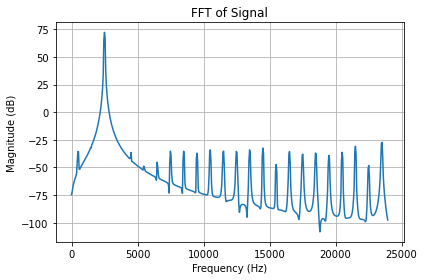

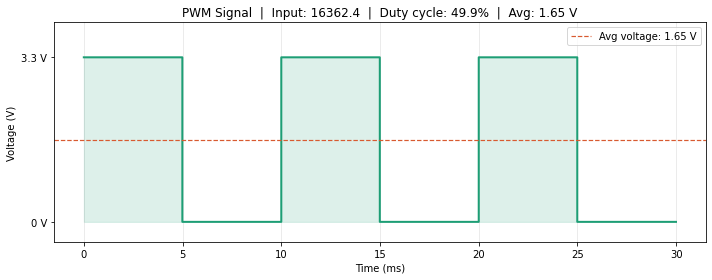

0.49935605945005646
Duty % = 49
Period = 50000000


In [178]:
run()